In [18]:
# =========================
# 1. IMPORT LIBRARIES
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,5)

In [19]:
# =========================
# 2. LOAD DATA
# =========================

df = pd.read_csv("superstore_final_dataset (1).csv", encoding="latin1")

print("Shape:", df.shape)
print(df.head())


Shape: (9800, 18)
   Row_ID        Order_ID  Order_Date   Ship_Date       Ship_Mode Customer_ID  \
0       1  CA-2017-152156   8/11/2017  11/11/2017    Second Class    CG-12520   
1       2  CA-2017-152156   8/11/2017  11/11/2017    Second Class    CG-12520   
2       3  CA-2017-138688   12/6/2017  16/06/2017    Second Class    DV-13045   
3       4  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   
4       5  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   

     Customer_Name    Segment        Country             City       State  \
0      Claire Gute   Consumer  United States        Henderson    Kentucky   
1      Claire Gute   Consumer  United States        Henderson    Kentucky   
2  Darrin Van Huff  Corporate  United States      Los Angeles  California   
3    Sean O Donnel   Consumer  United States  Fort Lauderdale     Florida   
4    Sean O Donnel   Consumer  United States  Fort Lauderdale     Florida   

   Postal_Code Region       Prod

In [20]:
# =========================
# 3. CLEAN DATA
# =========================

# Remove duplicates
df = df.drop_duplicates()

# Convert dates safely
df["Order_Date"] = pd.to_datetime(df["Order_Date"], errors="coerce")
df["Ship_Date"] = pd.to_datetime(df["Ship_Date"], errors="coerce")

# Drop rows where critical dates are missing
df = df.dropna(subset=["Order_Date", "Ship_Date", "Sales", "Order_ID"])

In [21]:
# =========================
# 4. FEATURE ENGINEERING
# =========================

df["Year"] = df["Order_Date"].dt.year
df["Month"] = df["Order_Date"].dt.month
df["Month_Name"] = df["Order_Date"].dt.strftime("%b")

# Shipping delay (in days)
df["Shipping_Delay"] = (df["Ship_Date"] - df["Order_Date"]).dt.days

In [22]:
# =========================
# 5. KPI CALCULATIONS (SAFE)
# =========================

total_sales = df["Sales"].sum()

total_orders = df["Order_ID"].nunique()

total_customers = df["Customer_ID"].nunique()

# Average Order Value (AOV)
aov = df.groupby("Order_ID")["Sales"].sum().mean()

# Average Customer Value
avg_customer_value = df.groupby("Customer_ID")["Sales"].sum().mean()

# Items per order (basket size)
basket_size = df.groupby("Order_ID")["Row_ID"].count().mean()


print("\n================ KPI SUMMARY ================\n")
print("Total Sales:", round(total_sales, 2))
print("Total Orders:", total_orders)
print("Total Customers:", total_customers)
print("Average Order Value (AOV):", round(aov, 2))
print("Avg Customer Value:", round(avg_customer_value, 2))
print("Avg Basket Size:", round(basket_size, 2))


================ KPI SUMMARY ================

Total Sales: 619168.22
Total Orders: 1332
Total Customers: 665
Average Order Value (AOV): 464.84
Avg Customer Value: 931.08
Avg Basket Size: 2.01


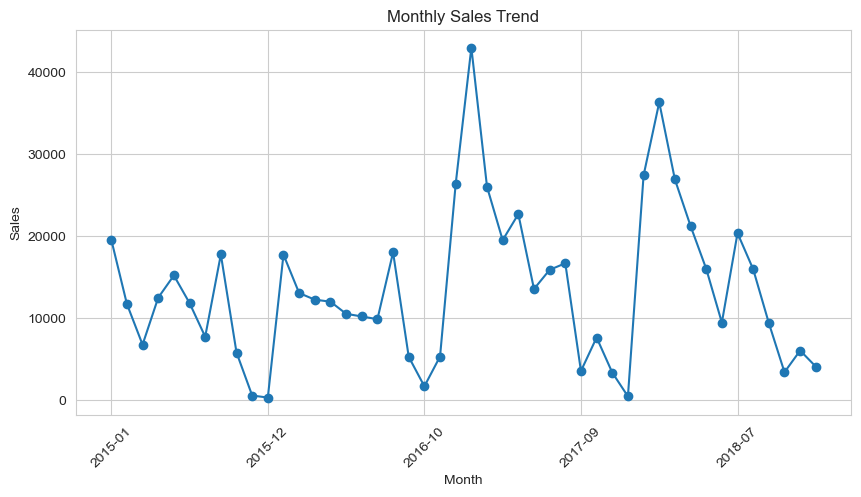

In [23]:
# =========================
# 6. MONTHLY SALES TREND
# =========================

monthly_sales = df.groupby(df["Order_Date"].dt.to_period("M"))["Sales"].sum()

monthly_sales.index = monthly_sales.index.astype(str)

plt.figure()
monthly_sales.plot(marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()


Category Sales:
 Category
Office Supplies    170036.1260
Furniture          196832.7749
Technology         252299.3230
Name: Sales, dtype: float64


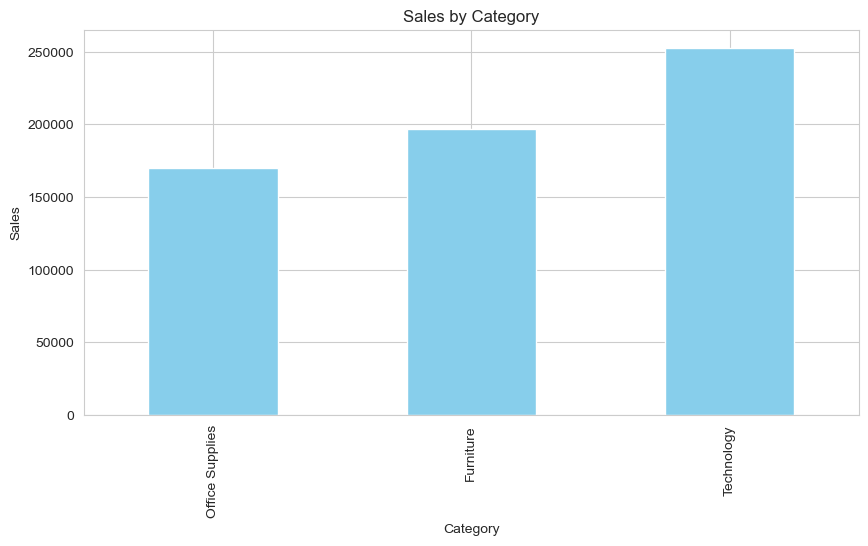

In [24]:
# =========================
# 7. CATEGORY ANALYSIS
# =========================

cat_sales = df.groupby("Category")["Sales"].sum().sort_values()

print("\nCategory Sales:\n", cat_sales)

plt.figure()
cat_sales.plot(kind="bar", color="skyblue")
plt.title("Sales by Category")
plt.ylabel("Sales")
plt.show()



Sub-Category Sales (Top 10 Worst to Best):
Sub_Category
Fasteners        776.9800
Labels          3543.0060
Envelopes       3799.4340
Art             8674.5720
Supplies       11755.1760
Paper          20647.4520
Furnishings    23646.0860
Appliances     25046.9740
Bookcases      31091.8254
Binders        42047.1360
Name: Sales, dtype: float64


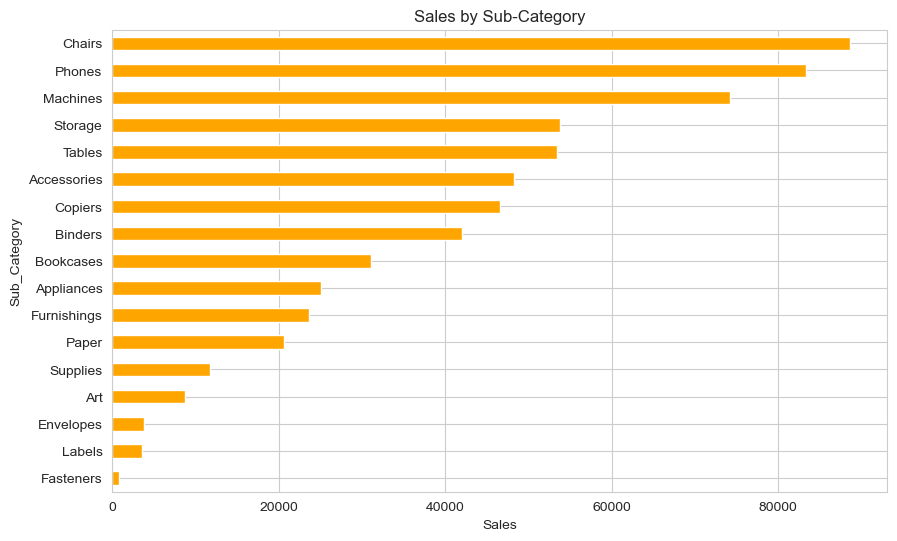

In [25]:
# =========================
# 8. SUB-CATEGORY ANALYSIS
# =========================

subcat_sales = df.groupby("Sub_Category")["Sales"].sum().sort_values()

print("\nSub-Category Sales (Top 10 Worst to Best):")
print(subcat_sales.head(10))

plt.figure(figsize=(10,6))
subcat_sales.plot(kind="barh", color="orange")
plt.title("Sales by Sub-Category")
plt.xlabel("Sales")
plt.show()


Region Sales:
 Region
South      113827.5395
Central    147409.9664
East       177009.4730
West       180921.2450
Name: Sales, dtype: float64


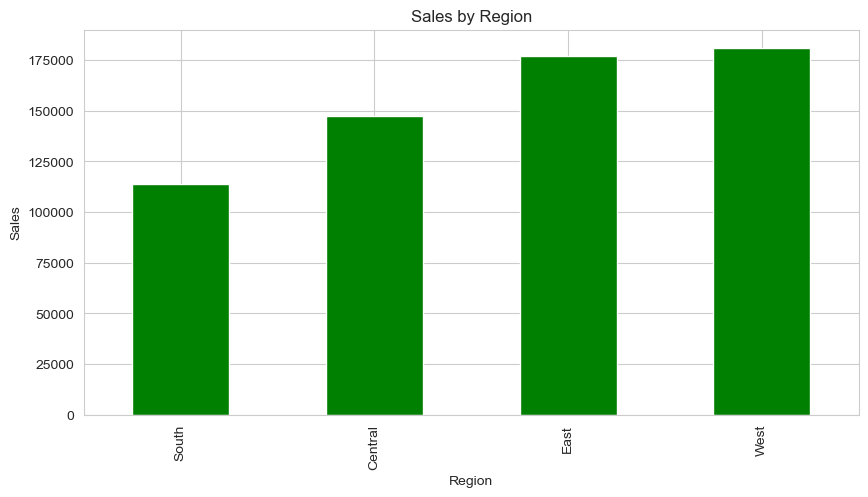

In [26]:
# =========================
# 9. REGION ANALYSIS
# =========================

region_sales = df.groupby("Region")["Sales"].sum().sort_values()

print("\nRegion Sales:\n", region_sales)

plt.figure()
region_sales.plot(kind="bar", color="green")
plt.title("Sales by Region")
plt.ylabel("Sales")
plt.show()



Top 10 Products:
 Product_Name
Canon imageCLASS 2200 Advanced Copier                            17499.9500
Lexmark MX611dhe Monochrome Laser Printer                        11219.9340
HP Designjet T520 Inkjet Large Format Printer - 24 Color          8749.9500
Riverside Palais Royal Lawyers Bookcase, Royale Cherry Finish     8298.8316
Hewlett Packard LaserJet 3310 Copier                              8159.8640
Cubify CubeX 3D Printer Triple Head Print                         7999.9800
Global Deluxe High-Back Managers Chair                            5948.3840
Hon Deluxe Fabric Upholstered Stacking Chairs, Rounded Back       5635.9380
GBC DocuBind P400 Electric Binding System                         5443.9600
Bady BDG101FRU Card Printer                                       5439.9320
Name: Sales, dtype: float64


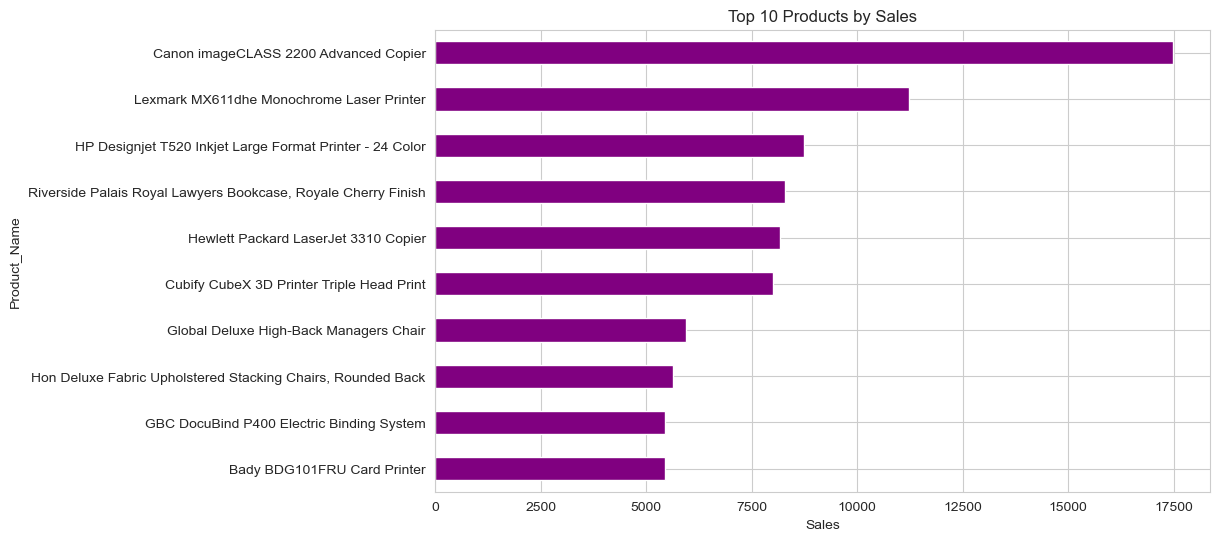

In [27]:

# =========================
# 10. TOP PRODUCTS
# =========================

top_products = df.groupby("Product_Name")["Sales"].sum().sort_values(ascending=False).head(10)

print("\nTop 10 Products:\n", top_products)

plt.figure(figsize=(10,6))
top_products.plot(kind="barh", color="purple")
plt.gca().invert_yaxis()
plt.title("Top 10 Products by Sales")
plt.xlabel("Sales")
plt.show()


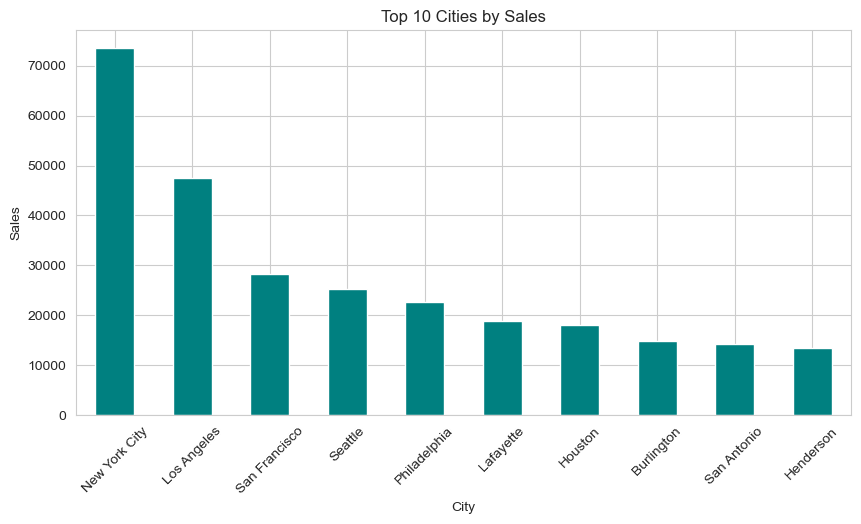

In [28]:
# =========================
# 11. TOP CITIES
# =========================

top_cities = df.groupby("City")["Sales"].sum().sort_values(ascending=False).head(10)

plt.figure()
top_cities.plot(kind="bar", color="teal")
plt.title("Top 10 Cities by Sales")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

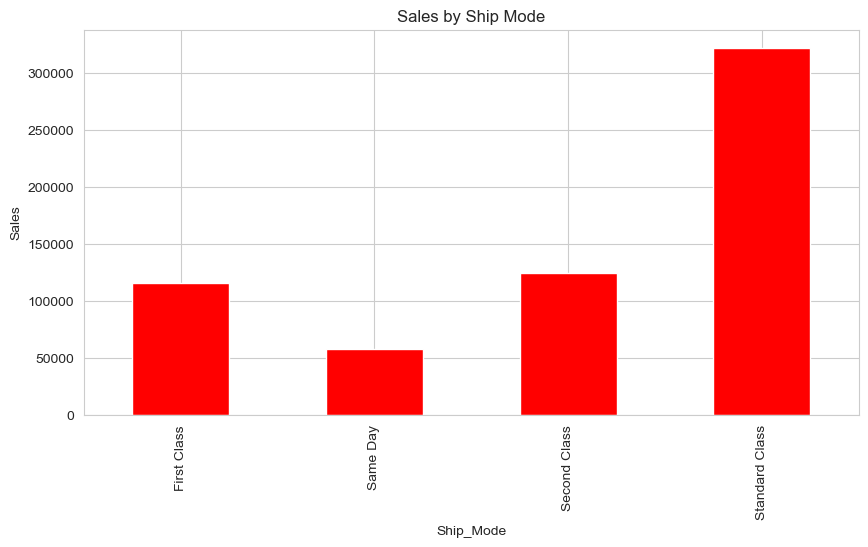

In [29]:
# =========================
# 12. SHIPPING ANALYSIS
# =========================

ship_mode_sales = df.groupby("Ship_Mode")["Sales"].sum()

plt.figure()
ship_mode_sales.plot(kind="bar", color="red")
plt.title("Sales by Ship Mode")
plt.ylabel("Sales")
plt.show()

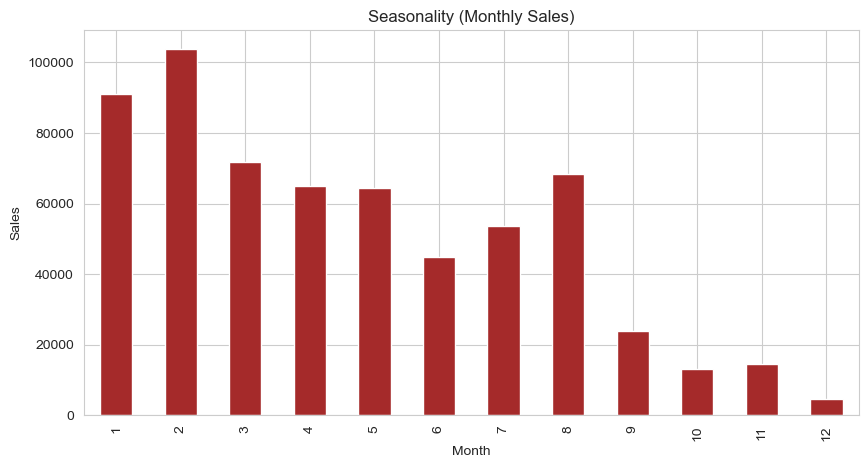

In [30]:
# =========================
# 13. SEASONALITY ANALYSIS
# =========================

monthly_seasonality = df.groupby("Month")["Sales"].sum().sort_index()

plt.figure()
monthly_seasonality.plot(kind="bar", color="brown")
plt.title("Seasonality (Monthly Sales)")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()



Average Shipping Delay (days): 107.01


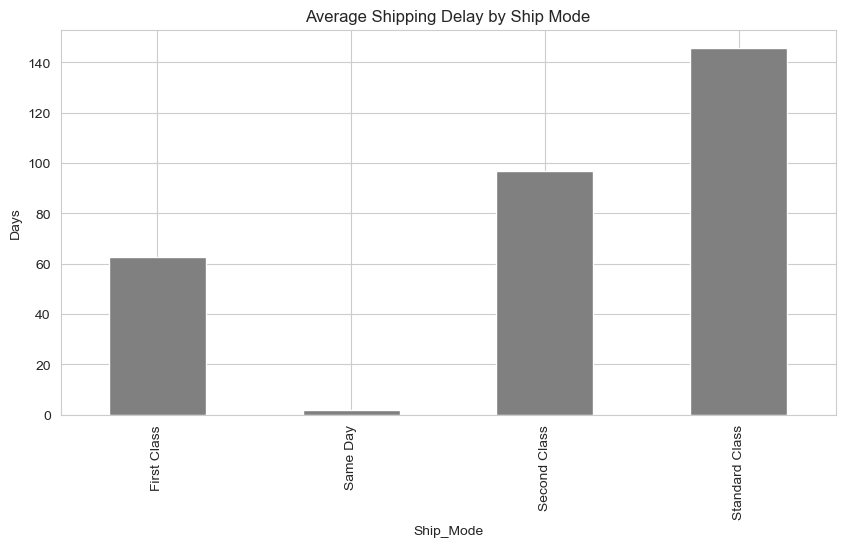

In [31]:
# =========================
# 14. SHIPPING DELAY ANALYSIS
# =========================

avg_delay = df["Shipping_Delay"].mean()

print("\nAverage Shipping Delay (days):", round(avg_delay, 2))

delay_by_shipmode = df.groupby("Ship_Mode")["Shipping_Delay"].mean()

plt.figure()
delay_by_shipmode.plot(kind="bar", color="gray")
plt.title("Average Shipping Delay by Ship Mode")
plt.ylabel("Days")
plt.show()


In [32]:
# =========================
# 15. FINAL INSIGHTS
# =========================

print("\n=========== BUSINESS INSIGHTS ===========\n")

print("1. Sales show clear seasonal patterns across months.")
print("2. A few products contribute disproportionately to revenue (Pareto effect).")
print("3. Region-wise performance is uneven, indicating market imbalance.")
print("4. Shipping mode impacts delivery time significantly.")
print("5. Customer value varies heavily, showing opportunity for segmentation.")


=========== BUSINESS INSIGHTS ===========

1. Sales show clear seasonal patterns across months.
2. A few products contribute disproportionately to revenue (Pareto effect).
3. Region-wise performance is uneven, indicating market imbalance.
4. Shipping mode impacts delivery time significantly.
5. Customer value varies heavily, showing opportunity for segmentation.
